# Saturated Depth 

In [2]:
import argparse
import pandas as pd
import numpy as np
import rasterio
import os
import sys
# Cấu hình đường dẫn (Nên để tuyệt đối hoặc config riêng)
BASE_DIR = 'C:\Users\VIETDAT\Documents\5. Landslide_automation'
INPUT_DIR = os.path.join(BASE_DIR, 'Input')
OUTPUT_DIR = os.path.join(BASE_DIR, 'Output')

def calculate_risk(rain_intensity, duration):
    # 1. Đọc dữ liệu tĩnh
    print("Loading static data...")
    with rasterio.open(os.path.join(INPUT_DIR, 'DEM.tif')) as src:
        template_meta = src.meta.copy()
        height, width = src.shape

    terrain_data = pd.read_csv(os.path.join(INPUT_DIR, 'terrain_data.csv'))
    soil_props = pd.read_csv(os.path.join(INPUT_DIR, 'soil_properties.csv'))
    
    # Xử lý Slope
    terrain_data['Slope'] = terrain_data['Slope'].replace(-9999, np.nan)
    slope_rad = np.radians(terrain_data['Slope'].values)
    
    # 2. Thiết lập tham số mưa từ input n8n
    # Trong code gốc: Rt = 0.008236, t = 36. 
    # Ở đây chúng ta lấy từ tham số hàm
    Rt = rain_intensity # mm/h (hoặc đơn vị tương ứng code gốc)
    t = duration        # hours
    
    print(f"Running simulation with Rt={Rt}, t={t}...")

    # 3. Chuẩn bị hàm random (Giữ nguyên logic của bạn)
    def random_property(name, cov_applies_to_tan_phi=False):
        row = soil_props[soil_props['Properties'] == name]
        if not row.empty:
            mean = row['Value'].values[0]
            cov = row['COV'].values[0]
            if name == 'Friction Angle' and cov_applies_to_tan_phi:
                tan_phi_mean = np.tan(np.radians(mean))
                std_dev = tan_phi_mean * cov
                return np.random.normal(loc=tan_phi_mean, scale=std_dev)
            else:
                std_dev = mean * cov
                return np.random.normal(loc=mean, scale=std_dev)
        return 0

    # 4. Monte Carlo Simulation
    # Lưu ý: 2000 vòng lặp là khá nặng cho automation hàng ngày. 
    # Nếu chạy chậm, cân nhắc giảm xuống 500-1000 hoặc dùng vectorization tối ưu hơn.
    num_iterations = 1000 
    num_pixels = terrain_data.shape[0]
    
    monte_carlo_fs = np.zeros((num_pixels, num_iterations))
    
    # Pre-calculate constants to speed up loop
    curvature = terrain_data['Curvature'].values
    soil_depth = terrain_data['Soil_depth'].values
    gamma_water = 9.81
    safe_slope = np.sin(slope_rad) * np.cos(slope_rad) # Simplified for brevity

    for i in range(num_iterations):
        # Sampling
        porosity = max(random_property('Porosity'), 0.01)
        ks = max(random_property('Hydraulic conductivity'), 1e-6)
        gamma = random_property('Unit weight')
        tan_phi = random_property('Friction Angle', cov_applies_to_tan_phi=True)
        cohesion = random_property('Cohesion')

        # Logic tính toán Infinite Slope (Giữ nguyên logic của bạn)
        Vs = (ks * np.sin(slope_rad) * np.cos(slope_rad)) / porosity
        
        # Saturated depth calculation
        # Lưu ý: Công thức này của bạn phụ thuộc vào Rt (mưa)
        hw = (1 / porosity) * (Rt * t + t * (curvature / 2) * Vs * Rt * t)
        hw = np.clip(hw, 0, soil_depth) # Giới hạn 0 <= hw <= soil_depth

        # FS calculation
        numerator = cohesion + ((gamma * soil_depth - gamma_water * hw) * (np.cos(slope_rad) ** 2) * tan_phi)
        denominator = gamma * soil_depth * safe_slope
        
        # Avoid division by zero
        with np.errstate(divide='ignore', invalid='ignore'):
            fs = numerator / denominator
            fs[denominator == 0] = 1.5 # Giả định an toàn nếu mẫu = 0
        
        monte_carlo_fs[:, i] = fs

    # 5. Tính P_failure
    p_failure = np.mean(monte_carlo_fs <= 1, axis=1)
    
    # 6. Xuất file GeoTIFF kết quả
    output_filename = f'P_Failure_Rt{Rt}_t{t}.tif'
    output_path = os.path.join(OUTPUT_DIR, output_filename)
    
    # Hàm export_raster (viết lại ngắn gọn)
    result_2d = np.full((height, width), -9999.0, dtype=np.float32)
    # Map 1D array back to 2D using Row/Col from terrain_data
    rows = terrain_data['Row'].values.astype(int)
    cols = terrain_data['Col'].values.astype(int)
    
    # Cần lọc các index hợp lệ
    valid_idx = (rows < height) & (cols < width)
    result_2d[rows[valid_idx], cols[valid_idx]] = p_failure[valid_idx]

    with rasterio.open(
        output_path, 'w', driver='GTiff',
        height=height, width=width, count=1, dtype='float32',
        crs=template_meta['crs'], transform=template_meta['transform'], nodata=-9999
    ) as dst:
        dst.write(result_2d, 1)

    print(f"SUCCESS: {output_path}")
    # In ra đường dẫn file để n8n bắt lấy
    print(f"OUTPUT_FILE::{output_path}")

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument('--intensity', type=float, required=True, help='Rain intensity (Rt)')
    parser.add_argument('--duration', type=float, required=True, help='Rain duration (t)')
    args = parser.parse_args()
    
    calculate_risk(args.intensity, args.duration)

In [3]:
with rasterio.open('DEM.tif') as src:
    template_data = src.read(1)  # Đọc Header
    template_meta = src.meta.copy()  # Lưu metadata
    height, width = template_data.shape  # Gán kích thước raster
#Import Dataset
terrain_data = pd.read_csv('terrain_data.csv')
rainfall_data = pd.read_csv('rainfall_data.csv')
soil_props = pd.read_csv('soil_properties.csv')
nodata_mask_1d = np.array([
    np.isnan(template_data[int(row), int(col)])
    for row, col in zip(terrain_data['Row'], terrain_data['Col'])
])
terrain_data['Slope'] = terrain_data['Slope'].replace(-9999, np.nan)

#Hàm đọc file 
def random_property(name, cov_applies_to_tan_phi=False):
    row = soil_props[soil_props['Properties'] == name]
    if not row.empty:
        mean = row['Value'].values[0]
        cov = row['COV'].values[0]
        
        if name == 'Friction Angle' and cov_applies_to_tan_phi:
            tan_phi_mean = np.tan(np.radians(mean))
            std_dev = tan_phi_mean * cov
            return np.random.normal(loc=tan_phi_mean, scale=std_dev)
        else:
            std_dev = mean * cov
            return np.random.normal(loc=mean, scale=std_dev)
    else:
        raise ValueError(f"Property '{name}' not found!")

#Monte Carlo Settings
num_iterations = 2000
num_pixels = terrain_data.shape[0]
warnings.filterwarnings("ignore", category=RuntimeWarning)

#Hàm Export data
def export_raster(data, folder, filename):
    os.makedirs(folder, exist_ok=True)
    filepath = os.path.join(folder, filename)

    result_2d = np.full((height, width), np.nan, dtype=np.float32)
    for i in range(len(data)):
        row = int(terrain_data.loc[i, 'Row'])
        col = int(terrain_data.loc[i, 'Col'])
        if 0 <= row < height and 0 <= col < width:
            if not np.isnan(template_data[row, col]): # CHỈ GÁN NẾU DEM GỐC CÓ DỮ LIỆU (không phải NoData)
                result_2d[row, col] = data[i]
    
    # ĐỔI NaN THÀNH -9999 để GIS hiểu NoData
    result_2d[np.isnan(result_2d)] = -9999
    
    with rasterio.open(
        filepath,
        'w',
        driver='GTiff',
        height=height,
        width=width,
        count=1,
        dtype='float32',
        crs=template_meta['crs'],
        transform=template_meta['transform'],
        nodata=-9999
    ) as dst:
        dst.write(result_2d, 1)

    print(f"Đã lưu raster: {filepath}")

In [4]:
export_hours = 36
with_uncertainty = {}
without_uncertainty = {}
gamma_water = 9.81

slope_rad = np.radians(terrain_data['Slope'].values)
curvature = terrain_data['Curvature'].values
soil_depth = terrain_data['Soil_depth'].values

safe_slope = np.where(np.abs(np.sin(slope_rad) * np.cos(slope_rad)) < 1e-6, np.nan,
                      np.sin(slope_rad) * np.cos(slope_rad))

hour = export_hours

row = rainfall_data[rainfall_data['Hours Accumulated'] == export_hours]


Rt = 0.008236 #296.5 mm
t = export_hours

# Without Uncertainty
porosity_mean = soil_props.loc[soil_props['Properties'] == 'Porosity', 'Value'].values[0]
ks_mean = soil_props.loc[soil_props['Properties'] == 'Hydraulic conductivity', 'Value'].values[0]
gamma_mean = soil_props.loc[soil_props['Properties'] == 'Unit weight', 'Value'].values[0]
phi_mean = soil_props.loc[soil_props['Properties'] == 'Friction Angle', 'Value'].values[0]
cohesion_mean = soil_props.loc[soil_props['Properties'] == 'Cohesion', 'Value'].values[0]
    
Vs_mean = (ks_mean * np.sin(slope_rad) * np.cos(slope_rad)) / porosity_mean
hw_without = (1 / porosity_mean) * (Rt * t + t * (curvature / 2) * Vs_mean * Rt * t)
hw_without = np.where(hw_without < 0, 0, hw_without)
# Giới hạn saturated depth không vượt soil depth
hw_without = np.minimum(hw_without, soil_depth)
# Tính FS
numerator_without = cohesion_mean + ((gamma_mean * soil_depth - gamma_water * hw_without) * (np.cos(slope_rad) ** 2) * np.tan(np.radians(phi_mean)))
denominator_without = gamma_mean * soil_depth * safe_slope
fs_without = numerator_without / denominator_without
fs_without = np.where(fs_without < 0, 0, fs_without)
# Giữ nguyên NoData từ DEM
fs_without = np.where(nodata_mask_1d, -9999, fs_without)
# Nếu còn NaN thì thay bằng 100
fs_without = np.where(np.isnan(fs_without), 1.5, fs_without)


# With Uncertainty
monte_carlo_results = np.zeros((num_pixels, num_iterations))
monte_carlo_fs = np.zeros((num_pixels, num_iterations))
for iteration in range(num_iterations):
    porosity = max(random_property('Porosity'), 0.01)  # đảm bảo > 0
    ks = max(random_property('Hydraulic conductivity'), 1e-6)
    gamma = random_property('Unit weight')
    
    tan_phi = random_property('Friction Angle', cov_applies_to_tan_phi=True)
    cohesion = random_property('Cohesion')
        
    Vs = (ks * np.sin(slope_rad) * np.cos(slope_rad)) / porosity
    hw = (1 / porosity) * (Rt * t + t * (curvature / 2) * Vs * Rt * t)
    hw = np.where(hw < 0, 0, hw)
    # Giới hạn saturated depth không vượt soil depth
    hw = np.minimum(hw, soil_depth)
        
    # Tính FS
    numerator = cohesion + ((gamma * soil_depth - gamma_water * hw) * (np.cos(slope_rad) ** 2) * tan_phi)
    denominator = gamma * soil_depth * safe_slope
    fs = numerator / denominator
    fs = np.where(fs < 0, 0, fs)  # Chặn FS âm
    fs = np.where(nodata_mask_1d, -9999, fs)
    fs = np.where(np.isnan(fs), 1.5, fs)

        
    monte_carlo_results[:, iteration] = hw
    monte_carlo_fs[:, iteration] = fs
        
#Tính P
p_failure = np.mean(monte_carlo_fs <= 1, axis=1)
p_failure = np.where(nodata_mask_1d, -9999, p_failure)

hw_with = np.nanmean(monte_carlo_results, axis=1)
fs_with = np.nanmean(monte_carlo_fs, axis=1)

with_uncertainty[hour] = hw_with
without_uncertainty[hour] = hw_without


#Xuất file
export_raster(fs_with, 'DataExport/FS/With Uncertainty', f'FS_WithUncertainty_Hour{hour}_test3.tif')
export_raster(fs_without, 'DataExport/FS/Without Uncertainty', f'FS_WithoutUncertainty_Hour{hour}_test3.tif')
export_raster(p_failure, 'DataExport/FS/P_failure', f'P_Failure_Hour{hour}_test3.tif')

    


Đã lưu raster: DataExport/FS/With Uncertainty\FS_WithUncertainty_Hour36_test3.tif
Đã lưu raster: DataExport/FS/Without Uncertainty\FS_WithoutUncertainty_Hour36_test3.tif
Đã lưu raster: DataExport/FS/P_failure\P_Failure_Hour36_test3.tif


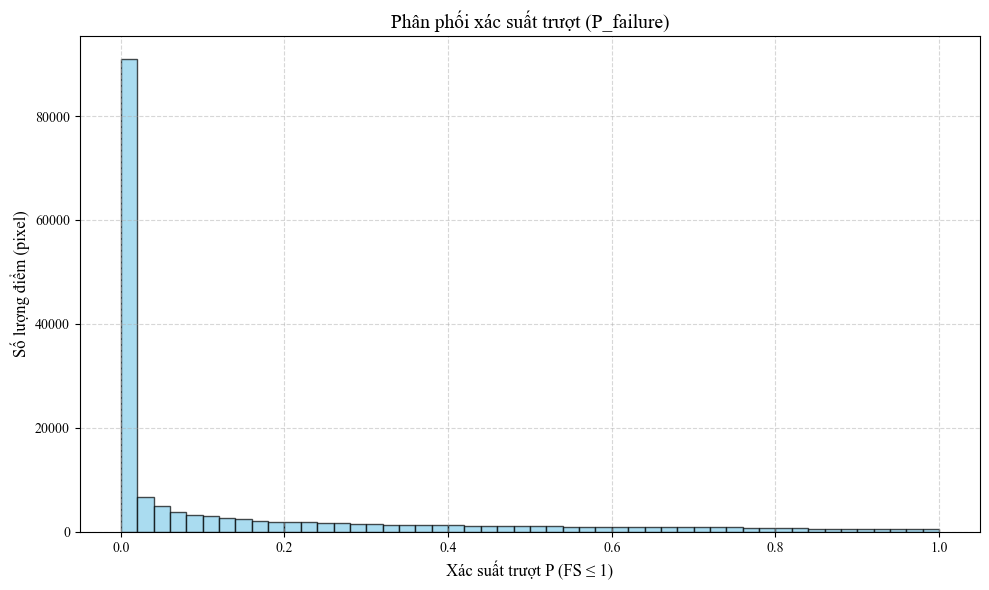

In [5]:
import matplotlib.pyplot as plt
p_nonzero = p_failure[p_failure >= 0]
plt.figure(figsize=(10, 6))
plt.hist(p_nonzero, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

plt.title("Phân phối xác suất trượt (P_failure)", fontsize=14)
plt.xlabel("Xác suất trượt P (FS ≤ 1)", fontsize=12)
plt.ylabel("Số lượng điểm (pixel)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

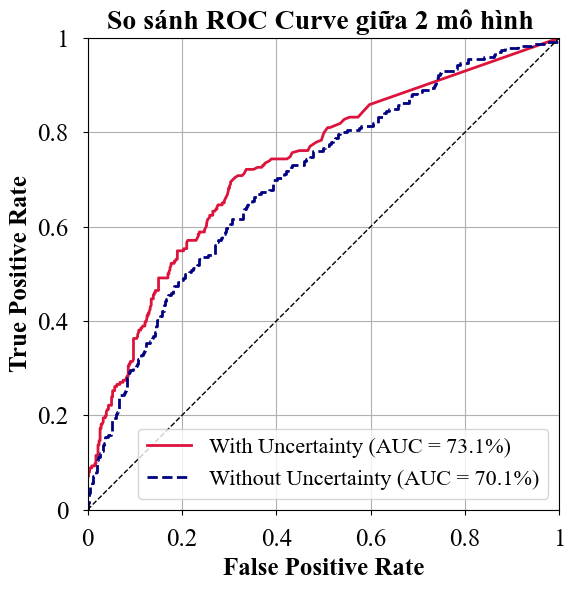

In [18]:
from sklearn.metrics import roc_curve, auc
from rasterio.features import rasterize
from rasterio.transform import xy
from matplotlib import rcParams
rcParams['font.family'] = 'Times New Roman'
np.random.seed(5)

# THAM SỐ 
NEG_RATIO = 2                 # số non-slide / số slide
SLOPE_MIN, SLOPE_MAX = 5.25, 30.15   # khoảng dốc để chọn non-slide theo slope

# Input 
inventory_folder = "Landslide inventory"
shapefile_path   = os.path.join(inventory_folder, "Landsliide inventory_point.shp")
points_gdf = gpd.read_file(shapefile_path)

raster_paths = {
    "With Uncertainty": {
        "path": os.path.join("DataExport", "FS", "P_failure", "P_Failure_Hour36_test3.tif"),
        "color": "crimson",
        "linestyle": "-"
    },
    "Without Uncertainty": {
        "path": os.path.join("DataExport", "FS", "Without Uncertainty", "FS_WithoutUncertainty_Hour36_test3.tif"),
        "color": "navy",
        "linestyle": "--"
    }
}

def safe_inv_fs(x, eps=1e-6, cap=50.0):
    """1/FS có chặn để tránh bùng số khi FS rất nhỏ."""
    inv = 1.0 / np.clip(x, eps, None)
    return np.clip(inv, 0.0, cap)

# 1) Chuẩn bị POOL negatives CHUNG theo SLOPE  
# Lấy shape/transform từ 1 raster
first_path = list(raster_paths.values())[0]["path"]
with rasterio.open(first_path) as src0:
    H, W = src0.height, src0.width
    transform = src0.transform
    res = max(abs(src0.res[0]), abs(src0.res[1]))

# Buffer quanh điểm trượt – 3 pixel
buf_dist = 3 * res
buf_geom = points_gdf.buffer(buf_dist)
buf_mask = rasterize([(g, 1) for g in buf_geom.geometry],
                     out_shape=(H, W), transform=transform, fill=0).astype(bool)

# Nạp slope từ Terrain_Data.csv vào grid
td = pd.read_csv("Terrain_Data.csv")
slope_arr = np.full((H, W), np.nan, dtype=float)
rr = td["Row"].astype(int).values
cc = td["Col"].astype(int).values
ss = td["Slope"].replace(-9999, np.nan).astype(float).values
ok = (rr>=0)&(rr<H)&(cc>=0)&(cc<W)
slope_arr[rr[ok], cc[ok]] = ss[ok]

# điểm negatives: ngoài buffer + có slope trong khoảng
neg_cand = (~buf_mask) & np.isfinite(slope_arr) & (slope_arr>=SLOPE_MIN) & (slope_arr<=SLOPE_MAX)
neg_rows, neg_cols = np.where(neg_cand)
if len(neg_rows) == 0:
    raise RuntimeError("Nới SLOPE_MIN/MAX hoặc giảm buffer.")

# --- 2) Vẽ ROC cho từng raster, dùng CHUNG pool theo slope ---
plt.figure(figsize=(6, 6))

# Khai báo trước vòng lặp
roc_rows = []      # lưu các điểm ROC (FPR, TPR, Threshold) kèm Model, X, Y
auc_rows = []      # lưu AUC theo Model
sample_rows = []  # lưu mẫu pixel với toạ độ X,Y để đối chiếu

for label, props in raster_paths.items():
    path = props["path"]
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan

        # Positive (slide)
        pos_vals, pos_rc = [], []
        for geom in points_gdf.geometry:
            try:
                r, c = src.index(geom.x, geom.y)
                v = arr[r, c]
                if np.isfinite(v):
                    pos_vals.append(v)
                    pos_rc.append((r, c))
            except Exception:
                continue
        pos_vals = np.array(pos_vals, dtype=float)
        if pos_vals.size == 0:
            raise RuntimeError(f"Không trích được giá trị tại điểm trượt cho: {label}")
        pos_rows = np.array([rc[0] for rc in pos_rc], dtype=int)  # >>> NEW
        pos_cols = np.array([rc[1] for rc in pos_rc], dtype=int)  # >>> NEW

        # Rút negatives CHUNG theo slope (không theo điểm số mô hình)
        num_neg = min(int(pos_vals.size * NEG_RATIO), len(neg_rows))
        sel = np.random.choice(len(neg_rows), size=num_neg, replace=False)
        coords_neg = np.column_stack([neg_rows[sel], neg_cols[sel]])
        neg_vals = np.array([arr[r, c] for r, c in coords_neg], dtype=float)
        good_neg = np.isfinite(neg_vals)
        neg_vals = neg_vals[np.isfinite(neg_vals)]
        coords_neg = coords_neg[good_neg]  # (đồng bộ toạ độ sau khi lọc NaN)

        # Labels
        y_true = np.r_[np.ones(pos_vals.size), np.zeros(neg_vals.size)]

        # Score: With = P_failure; Without = 1/FS
        is_pfail = ("p_failure" in os.path.basename(path).lower())
        if is_pfail:
            score_pos = pos_vals            
            score_neg = neg_vals
        else:
            score_pos = safe_inv_fs(pos_vals)  # >>> NEW
            score_neg = safe_inv_fs(neg_vals)  # >>> NEW
        score = np.r_[score_pos, score_neg]

        # tính toạ độ địa lý X,Y cho từng pixel dùng trong ROC
        pos_X, pos_Y = xy(src.transform, pos_rows, pos_cols, offset='center')
        neg_X, neg_Y = xy(src.transform, coords_neg[:, 0], coords_neg[:, 1], offset='center')

        # lưu bảng mẫu pixel (để đối chiếu/so sánh trên Excel)
        for (r, c, x, y, val, sc) in zip(pos_rows, pos_cols, pos_X, pos_Y, pos_vals, score_pos):
            sample_rows.append({
                "Model": label, "Label": 1,
                "Row": int(r), "Col": int(c), "X": float(x), "Y": float(y),
                "Value": float(val), "Score": float(sc)
            })
        for (r, c, x, y, val, sc) in zip(coords_neg[:,0], coords_neg[:,1], neg_X, neg_Y, neg_vals, score_neg):
            sample_rows.append({
                "Model": label, "Label": 0,
                "Row": int(r), "Col": int(c), "X": float(x), "Y": float(y),
                "Value": float(val), "Score": float(sc)
            })
        # ROC
        good = np.isfinite(score)
        fpr, tpr, thr = roc_curve(y_true[good], score[good], drop_intermediate=False)
        roc_auc = auc(fpr, tpr)

        # Thu thập điểm ROC cho CSV (X=FPR, Y=TPR)
        for f, t, th in zip(fpr, tpr, thr):
            roc_rows.append({
                "Model": label,
                "FPR": float(f),
                "TPR": float(t),
                "Threshold": float(th),
                "X": float(f),   # để vẽ nhanh trong Excel
                "Y": float(t)
            })

        # (tuỳ chọn) lưu AUC theo Model
        auc_rows.append({"Model": label, "AUC": float(roc_auc)})

        plt.plot(fpr, tpr,
                 label=f"{label} (AUC = {roc_auc*100:.1f}%)",
                 color=props["color"], linestyle=props["linestyle"], linewidth=2)

# Đường chéo & style như cũ
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title("So sánh ROC Curve giữa 2 mô hình ",
          fontname='Times New Roman', fontsize=20, fontweight='bold')
plt.xlabel("False Positive Rate",
           fontname='Times New Roman', fontsize=18, fontweight='bold')
plt.ylabel("True Positive Rate",
           fontname='Times New Roman', fontsize=18, fontweight='bold')

ticks = np.round(np.linspace(0, 1, 6), 1)
tick_labels = [str(int(t)) if t == int(t) else str(t) for t in ticks]
plt.xticks(ticks, tick_labels, fontname='Times New Roman', fontsize=18)
plt.yticks(ticks, tick_labels, fontname='Times New Roman', fontsize=18)
plt.legend(prop={'family': 'Times New Roman', 'size': 16})
plt.grid(True); plt.axis("square"); plt.xlim(0,1); plt.ylim(0,1)
ax = plt.gca(); ax.tick_params(axis='x', pad=10); ax.tick_params(axis='y', pad=10)
# === Lưu hình & CSV vào DataExport/ROC_Result ===
out_dir = os.path.join("DataExport", "ROC_Result")
os.makedirs(out_dir, exist_ok=True)

# Lưu hình
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "ROC_comparison_V3.png"), dpi=300)
plt.show()

# Lưu CSV
df_points  = pd.DataFrame(roc_rows)          # các điểm trên đường ROC
df_samples = pd.DataFrame(sample_rows)       # toàn bộ pixel (có X,Y)

df_points.to_csv(os.path.join(out_dir, "ROC_points_XY.csv"), index=False)
df_samples.to_csv(os.path.join(out_dir, "ROC_samples_with_coords.csv"), index=False)
pd.DataFrame(auc_rows).to_csv(os.path.join(out_dir, "ROC_AUC_summary.csv"), index=False)